# LUNA16 — Preprocessing & Validation UNet 2D
### Master 2 Thesis — Digital Twins of Lungs

**Pipeline optimized for Google Colab (limited disk space):**
1. Download **per subset** (subset0 → subset1 → subset2) from `Yousra0x0/LUNA16_RAW`
2. Preprocessing (HU clip, normalization, slice selection, resize 128³) → `.h5`
3. Immediate upload of `.h5` files to HuggingFace → disk freed
4. Slice-by-slice validation with model `hourouu/model4`
5. Automatic saving of results to HuggingFace

> **Important**: run cells in order. Never skip Cell 2.


## Cell 1 — Install Dependencies

In [1]:
!pip install -q huggingface_hub SimpleITK h5py scipy scikit-image tqdm

import importlib, sys
for pkg in ["SimpleITK", "h5py", "numpy", "scipy", "skimage", "tqdm", "torch", "huggingface_hub"]:
    try:
        importlib.import_module(pkg if pkg != "skimage" else "skimage")
        print(f"  OK: {pkg}")
    except ImportError:
        print(f"  MISSING: {pkg}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.8 MB/s eta 0:00:00
  OK: SimpleITK
  OK: h5py
  OK: numpy
  OK: scipy
  OK: skimage
  OK: tqdm
  OK: torch
  OK: huggingface_hub


## Cell 2 — Configuration

In [2]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from huggingface_hub import login
login(HF_TOKEN)

In [3]:
import os, torch, shutil

# -- HuggingFace Token ------------------------------------------------
# Required ONLY for writing to hourouu/
# The hourouu/model4 repo is PUBLIC -> no token required for reading

# -- HuggingFace Repos ------------------------------------------------
REPO_DATA_RAW  = "Yousra0x0/LUNA16_RAW"           # raw data (input)
REPO_MODEL     = "hourouu/model4"           # UNetV2 model (read-only, PUBLIC repo)
REPO_H5_OUTPUT = "hourouu/LUNA16_preprocessed"  # preprocessed .h5 files (output)
REPO_RESULTS   = "hourouu/LUNA16_validation"    # validation results (output)

from huggingface_hub import HfApi

api = HfApi()
REPO_RESULTS = "hourouu/LUNA16_validation"

api.create_repo(repo_id=REPO_RESULTS, repo_type="dataset", exist_ok=True)
print(f" Repo ready : https://huggingface.co/datasets/{REPO_RESULTS}")

# Test repo creation
REPO_H5_OUTPUT = "hourouu/LUNA16_preprocessed"

api.create_repo(repo_id=REPO_H5_OUTPUT, repo_type="dataset", exist_ok=True)
print(f" Repo ready : https://huggingface.co/datasets/{REPO_H5_OUTPUT}")


# -- Subsets to process (in Yousra0x0/LUNA16_RAW) --------------------
SUBSET_FOLDERS = [ "subset0","subset1", "subset2", "subset3", "subset4", "subset5", "subset6"]
MASK_FOLDER    = "seg-lungs-LUNA16"                     # mask folder in the repo

# -- Local Colab directories (temporary) -----------------------------
DIR_RAW     = "/content/luna16_raw_tmp"
DIR_H5      = "/content/preprocessed"
DIR_RESULTS = "/content/results"

# -- Preprocessing parameters ----------------------------------------
HU_MIN          = -1000
HU_MAX          = 200
TARGET_SHAPE    = (128, 128, 128)
MIN_SLICES      = 20
MAX_SLICES      = 120
MAX_EMPTY_RATIO = 0.10
EMPTY_THRESH    = 1e-5

# -- Validation parameters -------------------------------------------
THRESHOLD = 0.5
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(DIR_RAW,     exist_ok=True)
os.makedirs(DIR_H5,      exist_ok=True)
os.makedirs(DIR_RESULTS, exist_ok=True)

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"HF token: {'configured' if HF_TOKEN else 'NOT SET!'}")
print(f"Subsets: {SUBSET_FOLDERS}")
print(f"Masks: {MASK_FOLDER}")
print(f"REPO_MODEL (read-only, public): {REPO_MODEL}")


 Repo ready : https://huggingface.co/datasets/hourouu/LUNA16_validation
 Repo ready : https://huggingface.co/datasets/hourouu/LUNA16_preprocessed
Device: cuda
GPU: Tesla T4
HF token: configured
Subsets: ['subset0', 'subset1', 'subset2', 'subset3', 'subset4', 'subset5', 'subset6']
Masks: seg-lungs-LUNA16
REPO_MODEL (read-only, public): hourouu/model4


## Cell 3 — Preprocessing Functions

In [4]:
import numpy as np
import SimpleITK as sitk
from scipy.ndimage import zoom
from pathlib import Path

def load_mhd(path):
    """Load a .mhd + .raw/.zraw file -> numpy array (Z, Y, X) float32."""
    img = sitk.ReadImage(str(path))
    return sitk.GetArrayFromImage(img).astype(np.float32)

def hu_clip(volume):
    return np.clip(volume, HU_MIN, HU_MAX)

def minmax_normalize(volume):
    v_min, v_max = volume.min(), volume.max()
    if v_max - v_min < 1e-8:
        return np.zeros_like(volume)
    return (volume - v_min) / (v_max - v_min)

def select_valid_slices(volume, mask):
    n = volume.shape[0]
    empty_flags = np.array([volume[i].max() < EMPTY_THRESH for i in range(n)])
    if empty_flags.sum() / n > MAX_EMPTY_RATIO:
        return None, None
    valid_idx = np.where(~empty_flags)[0]
    if len(valid_idx) < MIN_SLICES:
        return None, None
    if len(valid_idx) > MAX_SLICES:
        c = len(valid_idx) // 2
        half = MAX_SLICES // 2
        valid_idx = valid_idx[c - half : c + half]
    return volume[valid_idx], mask[valid_idx]

def resize_volume(volume, target=TARGET_SHAPE):
    factors = [t / s for t, s in zip(target, volume.shape)]
    return zoom(volume, factors, order=1).astype(np.float32)

def preprocess_one(uid, ct_path, mask_path, out_dir):
    """Preprocess a (CT, mask) pair and save as .h5. Returns True on success."""
    import h5py
    ct   = load_mhd(ct_path)
    mask = load_mhd(mask_path)
    ct   = minmax_normalize(hu_clip(ct))
    mask = (mask > 0).astype(np.float32)
    ct, mask = select_valid_slices(ct, mask)
    if ct is None:
        return "rejected"
    ct   = resize_volume(ct)
    mask = resize_volume(mask)
    mask = (mask > 0.5).astype(np.float32)
    out_path = os.path.join(out_dir, f"{uid}.h5")
    with h5py.File(out_path, "w") as f:
        f.create_dataset("image", data=ct,   compression="gzip", compression_opts=4)
        f.create_dataset("mask",  data=mask, compression="gzip", compression_opts=4)
        f.attrs["patient_id"] = uid
        f.attrs["hu_clip"]    = f"[{HU_MIN}, {HU_MAX}]"
        f.attrs["norm"]       = "minmax [0,1]"
        f.attrs["shape"]      = str(TARGET_SHAPE)
    return "ok"

print("Preprocessing functions defined")
print(f"  HU clip: [{HU_MIN}, {HU_MAX}]")
print(f"  Target shape: {TARGET_SHAPE}")
print(f"  Slices min/max: {MIN_SLICES} / {MAX_SLICES}")


Preprocessing functions defined
  HU clip: [-1000, 200]
  Target shape: (128, 128, 128)
  Slices min/max: 20 / 120


## Cell 4 — UNetV2 Architecture

> Architecture identical to the one trained in `hourouu/model4`: InstanceNorm2d, base_ch=32.

In [5]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNetV2(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1 = ConvBlock(in_ch, b);   self.enc2 = ConvBlock(b,   b*2)
        self.enc3 = ConvBlock(b*2,  b*4);  self.enc4 = ConvBlock(b*4, b*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(b*8, b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x);               s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2));   s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.out(d1)

_t = UNetV2()(torch.randn(2, 1, 128, 128))
print(f"UNetV2 OK — output shape: {_t.shape}")
print(f"  Parameters: {sum(p.numel() for p in UNetV2().parameters()):,}")
del _t


UNetV2 OK — output shape: torch.Size([2, 1, 128, 128])
  Parameters: 7,762,465


## Cell 5 — Load Model from HuggingFace

In [6]:
from huggingface_hub import hf_hub_download

# hourouu/model4 : repo dataset public
# list_repo_files() appelle l'API /models → 401 even on public dataset repos
# Solution : download directly les files connus sans passer par l'API
print(f"Downloading weights from {REPO_MODEL} ...")

ckpt_path = None
for filename in ["best.pth", "latest.pth"]:
    try:
        ckpt_path = hf_hub_download(
            repo_id=REPO_MODEL,
            filename=filename,
            repo_type="dataset",   # hourouu/model4 est un dataset repo
            # pas de token — repo public, lecture libre
        )
        print(f"  Weights found: {filename}")
        weight_filename = filename
        break
    except Exception as e:
        print(f"  {filename} not found: {e}")

if ckpt_path is None:
    raise FileNotFoundError(
        f"Could not download weights from {REPO_MODEL}.\n"
        f"Make sure best.pth or latest.pth exists in the repo."
    )

# Instantiate UNetV2 — same architecture as the training repo
model = UNetV2(in_ch=1, base_ch=32).to(DEVICE)

# Load the checkpoint
ckpt = torch.load(ckpt_path, map_location=DEVICE)

# The hourouu/model4 format uses the 'model_state' key
if isinstance(ckpt, dict):
    if "model_state" in ckpt:
        state_dict = ckpt["model_state"]
        epoch_info = ckpt.get("epoch", "?")
        dice_info  = round(ckpt.get("best_dice", 0), 4)
        print(f"  Checkpoint: epoch={epoch_info}  best_dice={dice_info}")
    elif "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt
else:
    state_dict = ckpt

model.load_state_dict(state_dict, strict=True)
model.eval()
print(f"\nUNetV2 loaded on {DEVICE}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")


best.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

  Weights found: best.pth
  Checkpoint: epoch=7  best_dice=0.9044

UNetV2 loaded on cuda
  Parameters: 7,762,465


## Cell 6 — Metric Functions

In [7]:
from scipy.ndimage import distance_transform_edt

def dice_score(pred, target, eps=1e-6):
    inter = (pred * target).sum()
    return float((2*inter + eps) / (pred.sum() + target.sum() + eps))

def iou_score(pred, target, eps=1e-6):
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return float((inter + eps) / (union + eps))

def precision_recall_f1(pred, target, eps=1e-6):
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    prec = float((tp + eps) / (tp + fp + eps))
    rec  = float((tp + eps) / (tp + fn + eps))
    f1   = float(2 * prec * rec / (prec + rec + eps))
    return prec, rec, f1

def sensitivity_specificity(pred, target, eps=1e-6):
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    tn = ((1 - pred) * (1 - target)).sum()
    return float((tp+eps)/(tp+fn+eps)), float((tn+eps)/(tn+fp+eps))

def hausdorff_95(pred, target):
    pred_b, target_b = pred.astype(bool), target.astype(bool)
    if not pred_b.any() or not target_b.any():
        return float("nan")
    try:
        d_p2t = distance_transform_edt(~target_b)[pred_b]
        d_t2p = distance_transform_edt(~pred_b)[target_b]
        return float(np.percentile(np.concatenate([d_p2t, d_t2p]), 95))
    except Exception:
        return float("nan")

def volume_error(pred, target):
    vt = target.sum()
    return float("nan") if vt == 0 else float(abs(pred.sum()-vt)/vt*100)

def all_metrics(pred, target):
    pred, target = pred.astype(np.float32), target.astype(np.float32)
    prec, rec, f1 = precision_recall_f1(pred, target)
    sens, spec    = sensitivity_specificity(pred, target)
    return {"dice": dice_score(pred,target), "iou": iou_score(pred,target),
            "precision": prec, "recall": rec, "f1": f1,
            "sensitivity": sens, "specificity": spec,
            "hd95": hausdorff_95(pred,target), "vol_error_%": volume_error(pred,target)}

print("Metrics defined: Dice, IoU, Precision, Recall, F1, Sensitivity, Specificity, HD95, VolError")


Metrics defined: Dice, IoU, Precision, Recall, F1, Sensitivity, Specificity, HD95, VolError


## Cell 3b — Resume System (HuggingFace Checkpoint)

> Before each preprocessing step, the pipeline checks if the `.h5` already exists on `LUNA16_preprocessed`.
> If yes → **skip** (saves time and HF quota). The local `done_patients` registry is rebuilt on every startup.

In [8]:
from huggingface_hub import HfApi, list_repo_files
from pathlib import Path

api = HfApi(token=HF_TOKEN)

#
# Construire le registre des already-preprocessed patients sur HF
# by listing all .h5 files present in REPO_H5_OUTPUT
#
print(f"Scanning {REPO_H5_OUTPUT} to retrieve already-processed patients...")

done_patients = set()   # set of already-uploaded UIDs

try:
    all_hf_files = list(list_repo_files(
        repo_id=REPO_H5_OUTPUT,
        repo_type="dataset",
        token=HF_TOKEN
    ))
    for fpath in all_hf_files:
        if fpath.endswith(".h5"):
            uid = Path(fpath).stem   # ex: "subset0/1.2.3.4.h5" → "1.2.3.4"
            done_patients.add(uid)
    print(f"  {len(done_patients)} already-preprocessed patients found on HuggingFace")
except Exception as e:
    print(f"  Could not list the repo (empty repo or error): {e}")
    print(f"  -> Pipeline will start from scratch.")

# Display a preview
if done_patients:
    preview = list(done_patients)[:5]
    print(f"  Exemples : {preview}{'...' if len(done_patients) > 5 else ''}")
else:
    print("  → Aucun patient not yet processed, starting from scratch.")


Scanning hourouu/LUNA16_preprocessed to retrieve already-processed patients...
  0 already-preprocessed patients found on HuggingFace
  → Aucun patient not yet processed, starting from scratch.


## Cell 6b — Data Integrity Check (images vs masks)

> Cellule **Standalone cell**: only depends on the HF token and configuration constants.
> Run it independently from the pipeline to audit `Yousra0x0/LUNA16_RAW` avant tout traitement.
> It modifies nothing — read only.

In [11]:
#
# INTEGRITY CHECK — images vs masks in Yousra0x0/LUNA16_RAW
# Standalone cell: only uses HF_TOKEN + the constants below
# Read-only — nothing is modified or uploaded
#
from huggingface_hub import list_repo_files
from pathlib import Path
from collections import defaultdict

# -- Configuration (same as Cell 2) ------------------------------------------
REPO_DATA_RAW  = "Yousra0x0/LUNA16_RAW"
SUBSET_FOLDERS = ["subset0","subset1","subset2","subset3","subset4","subset5","subset6"]
MASK_FOLDER    = "seg-lungs-LUNA16"
# HF_TOKEN must be defined (Cell 2), otherwise uncomment:
# HF_TOKEN = "hf_..."

# -- 1. List all files in the repo -------------------------------------------
print(f"Listing files in {REPO_DATA_RAW} ...")
try:
    all_files = list(list_repo_files(
        repo_id=REPO_DATA_RAW,
        repo_type="dataset",
        token=HF_TOKEN
    ))
    print(f"  {len(all_files)} files found in total\n")
except Exception as e:
    raise RuntimeError(f"Could not list {REPO_DATA_RAW}: {e}")

#  2. Separate CT images and masks by subset
# Un fichier CT est un .mhd in un dossier subset*
# Un fichier mask est un .mhd in le dossier MASK_FOLDER

ct_by_subset   = defaultdict(set)   # subset → set d'UIDs CT
mask_uids      = set()              # UIDs masks (sans suffixe _segmentation etc.)
extra_ct_ext   = defaultdict(set)   # subset → set of associated .raw/.zraw files
extra_mask_ext = set()

for fpath in all_files:
    p = Path(fpath)
    parts = p.parts   # ex: ("subset0", "1.2.3.4.mhd")

    # -- Masks -------------------------------------------------------------------
    if parts[0] == MASK_FOLDER:
        if p.suffix == ".mhd":
            uid = p.stem
            for suffix in ["_segmentation", "-seg", "_seg", "-segmentation"]:
                uid = uid.replace(suffix, "")
            mask_uids.add(uid)
        elif p.suffix in (".raw", ".zraw"):
            extra_mask_ext.add(p.name)

    # -- CT scans ----------------------------------------------------------------
    elif parts[0] in SUBSET_FOLDERS:
        subset = parts[0]
        if p.suffix == ".mhd":
            ct_by_subset[subset].add(p.stem)
        elif p.suffix in (".raw", ".zraw"):
            extra_ct_ext[subset].add(p.name)

# -- 3. Display raw content per subset ---------------------------------------
print(""*60)
print(f"  MASKS ({MASK_FOLDER}): {len(mask_uids)} UIDs found")
print(f"  Subsets scanned: {SUBSET_FOLDERS}")
print(""*60)

all_ct_uids = set()
for sub in SUBSET_FOLDERS:
    n = len(ct_by_subset[sub])
    all_ct_uids |= ct_by_subset[sub]
    print(f"  {sub:<12} : {n:>4} CT  |  {len(extra_ct_ext[sub]):>4} .raw/.zraw")
print(f"  {'TOTAL':<12} : {len(all_ct_uids):>4} CT  |  {len(mask_uids):>4} masks")

# -- 4. Cross-analysis: images without mask / masks without image -------------
images_sans_mask = all_ct_uids - mask_uids
masks_sans_image = mask_uids   - all_ct_uids
images_avec_mask = all_ct_uids & mask_uids

print(f"\n{''*60}")
print(f"  AUDIT RESULT")
print(f"{''*60}")
print(f"  Images WITH matching mask: {len(images_avec_mask)}")
print(f"  Images WITHOUT mask: {len(images_sans_mask)}")
print(f"  Masks WITHOUT image: {len(masks_sans_image)}")

# -- 5. Detail per subset ----------------------------------------------------
print(f"\n{''*60}")
print(f"  DETAIL PER SUBSET")
print(f"{''*60}")

any_issue = False
for sub in SUBSET_FOLDERS:
    uids = ct_by_subset[sub]
    sans_mask  = uids - mask_uids
    avec_mask  = uids & mask_uids
    pct = 100 * len(avec_mask) / len(uids) if uids else 0
    status = "" if not sans_mask else ""
    print(f"  {status} {sub:<12}: {len(avec_mask):>3}/{len(uids):>3} images have a mask ({pct:.0f}%)")
    if sans_mask:
        any_issue = True
        preview = sorted(sans_mask)[:5]
        print(f"       Sans mask : {preview}{'...' if len(sans_mask)>5 else ''}")

# -- 6. List problematic cases -----------------------------------------------
if images_sans_mask:
    print(f"\n{''*60}")
    print(f"  {len(images_sans_mask)} IMAGE(S) WITHOUT MASK — full list:")
    for uid in sorted(images_sans_mask):
        # Trouver in quel subset
        for sub in SUBSET_FOLDERS:
            if uid in ct_by_subset[sub]:
                print(f"    [{sub}]  {uid}")
                break

if masks_sans_image:
    print(f"\n{''*60}")
    print(f"  {len(masks_sans_image)} MASK(S) WITHOUT IMAGE — full list:")
    for uid in sorted(masks_sans_image):
        print(f"    {uid}")

if not images_sans_mask and not masks_sans_image:
    print(f"\n   Parfait — each image a son mask et vice-versa !")
else:
    print(f"\n    Attention : les UIDs sans a match will be skipped")
    print(f"       (stats['error'] += 1) lors du preprocessing.")

# -- 7. Check .mhd / .raw consistency ----------------------------------------
print(f"\n{''*60}")
print(f"  .mhd / .raw CONSISTENCY")
print(f"{''*60}")

for sub in SUBSET_FOLDERS:
    n_mhd = len(ct_by_subset[sub])
    n_raw = len(extra_ct_ext[sub])
    ratio = n_raw / n_mhd if n_mhd else 0
    status = "" if abs(ratio - 1.0) < 0.05 or n_mhd == 0 else " "
    print(f"  {status} {sub:<12}: {n_mhd} .mhd  {n_raw} .raw  (ratio {ratio:.2f})")

n_mask_raw = len(extra_mask_ext)
n_mask_mhd = len(mask_uids)
ratio_m = n_mask_raw / n_mask_mhd if n_mask_mhd else 0
status_m = "" if abs(ratio_m - 1.0) < 0.05 or n_mask_mhd == 0 else " "
print(f"  {status_m} {MASK_FOLDER:<12}: {n_mask_mhd} .mhd  {n_mask_raw} .raw  (ratio {ratio_m:.2f})")

print(f"\n{''*60}")
print(f"  AUDIT COMPLETE")
print(f"{''*60}")


Listing files in Yousra0x0/LUNA16_RAW ...
  3553 files found in total


  MASKS (seg-lungs-LUNA16): 888 UIDs found
  Subsets scanned: ['subset0', 'subset1', 'subset2', 'subset3', 'subset4', 'subset5', 'subset6']

  subset0      :   89 CT  |    89 .raw/.zraw
  subset1      :   89 CT  |    89 .raw/.zraw
  subset2      :   89 CT  |    89 .raw/.zraw
  subset3      :   89 CT  |    89 .raw/.zraw
  subset4      :   89 CT  |    89 .raw/.zraw
  subset5      :   89 CT  |    89 .raw/.zraw
  subset6      :   89 CT  |    89 .raw/.zraw
  TOTAL        :  623 CT  |   888 masks


  AUDIT RESULT

  Images WITH matching mask: 623
  Images WITHOUT mask: 0
  Masks WITHOUT image: 265


  DETAIL PER SUBSET

   subset0     :  89/ 89 images have a mask (100%)
   subset1     :  89/ 89 images have a mask (100%)
   subset2     :  89/ 89 images have a mask (100%)
   subset3     :  89/ 89 images have a mask (100%)
   subset4     :  89/ 89 images have a mask (100%)
   subset5     :  89/ 89 images have a mask (100%)


## Cell 7 — Main Pipeline: Preprocessing + Validation per Subset

> **Disk strategy**: for each subset, download → preprocess → upload .h5 → validate → delete raw files.
> The Colab disk (~80 GB) never stores more than one subset at a time.


In [12]:
import glob, shutil, json, h5py, os
from pathlib import Path
from tqdm.notebook import tqdm
from datetime import datetime
from huggingface_hub import snapshot_download, HfApi, list_repo_files, hf_hub_download

api = HfApi(token=HF_TOKEN)

#
# HELPER: list all files in a repo
# Returns a set of relative paths, ex {"subset0/1.2.3.h5", "validation/report.txt"}
#
def hf_list_all(repo_id, repo_type="dataset"):
    """List ALL files in the repo. Returns set() on failure."""
    try:
        files = set(list_repo_files(repo_id=repo_id, repo_type=repo_type, token=HF_TOKEN))
        return files
    except Exception as e:
        print(f"  hf_list_all({repo_id}) failed: {e}")
        return set()

def hf_list_subset_h5(repo_id, subset):
    """Returns the set of .h5 filenames present in subset/ on HF."""
    all_files = hf_list_all(repo_id)
    return {Path(fp).name for fp in all_files if fp.startswith(f"{subset}/") and fp.endswith(".h5")}

def hf_list_validation_files(repo_id):
    """Returns the set of filenames present in validation/ on HF."""
    all_files = hf_list_all(repo_id)
    return {Path(fp).name for fp in all_files if fp.startswith("validation/")}

#
# STEP 0 — Prepare output repos on HF
#
print("\n" + ""*60)
print("  STEP 0 — Verify / create HF repos (Yousra0x0)")
print(""*60)
for repo_id in [REPO_H5_OUTPUT, REPO_RESULTS]:
    try:
        api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)
        print(f"  Repo ready: {repo_id}")
    except Exception as e:
        print(f"  Repo {repo_id} error: {e}")

#
# STEP 1 — Initial scan de REPO_H5_OUTPUT (hourouu/LUNA16_preprocessed)
#            → construire done_patients et done_validated
#
print("\n" + ""*60)
print(f"  STEP 1 — Global scan of {REPO_H5_OUTPUT}")
print(""*60)

all_hf_h5_files = hf_list_all(REPO_H5_OUTPUT)  # ex: {"subset0/uid.h5", ...}

# done_patients: UIDs already preprocessed AND uploaded (to skip preprocessing)
done_patients = {Path(fp).stem for fp in all_hf_h5_files if fp.endswith(".h5")}

# Count per subset for report
for sub in SUBSET_FOLDERS:
    count = sum(1 for fp in all_hf_h5_files if fp.startswith(f"{sub}/") and fp.endswith(".h5"))
    print(f"  {sub:<12}: {count} .h5 already on HF")
print(f"  TOTAL: {len(done_patients)} patients already preprocessed")

#
# STEP 2 — Initial scan de REPO_RESULTS (hourouu/LUNA16_validation)
#            → savoir quels patients ont already validated
#
print("\n" + ""*60)
print(f"  STEP 2 — Global scan of {REPO_RESULTS}")
print(""*60)

all_hf_result_files = hf_list_all(REPO_RESULTS)

# done_validated: UIDs whose metrics are in validation_results.json
done_validated = set()
try:
    json_hf_path = hf_hub_download(
        repo_id=REPO_RESULTS,
        filename="validation/validation_results.json",
        repo_type="dataset",
        token=HF_TOKEN
    )
    with open(json_hf_path) as jf:
        existing_json = json.load(jf)
    done_validated = set(existing_json.get("per_patient", {}).keys())
    print(f"  validation_results.json found -> {len(done_validated)} patients already validated")
    # Pre-load existing metrics to avoid overwriting them
    all_results_global      = dict(existing_json.get("per_patient", {}))
    all_metrics_list_global = list(all_results_global.values())
except Exception as e:
    print(f"  No existing validation_results.json: {e}")
    print(f"  -> Starting validation from scratch.")
    done_validated      = set()
    all_results_global  = {}
    all_metrics_list_global = []

print(f"  Other files in REPO_RESULTS: {all_hf_result_files - {'validation/validation_results.json'}}")

#
# STEP 3 — Download masks ONCE FOIS (hourouu — lecture seule)
#
print("\n" + ""*60)
print(f"  STEP 3 — Downloading masks from {REPO_DATA_RAW} (read-only)")
print(""*60)

MASK_DIR_LOCAL = os.path.join(DIR_RAW, "masks_only")
os.makedirs(MASK_DIR_LOCAL, exist_ok=True)

snapshot_download(
    repo_id=REPO_DATA_RAW,
    repo_type="dataset",
    local_dir=MASK_DIR_LOCAL,
    token=HF_TOKEN,
    allow_patterns=[f"{MASK_FOLDER}/**", f"{MASK_FOLDER}/*"],
    ignore_patterns=["*.parquet", "*.arrow", "*.md"]
)
all_mask_mhd = glob.glob(os.path.join(MASK_DIR_LOCAL, "**", "*.mhd"), recursive=True)
mask_files   = {Path(f).stem.replace("_segmentation","").replace("-seg","").replace("_seg",""): f
                for f in all_mask_mhd}
print(f"  Masks found: {len(mask_files)}")

#
# STEP 4 — MAIN LOOP: one subset at a time
#
GLOBAL_STATS = {"ok": 0, "skipped": 0, "rejected": 0, "error": 0}
BATCH_SIZE   = 15   # ← files par commit HF (ajustable)

for subset in SUBSET_FOLDERS:
    print(f"\n{''*60}")
    print(f"  SUBSET : {subset}")
    print(f"{''*60}")

    subset_raw_dir = os.path.join(DIR_RAW, subset)
    subset_h5_dir  = os.path.join(DIR_H5,  subset)
    os.makedirs(subset_raw_dir, exist_ok=True)
    os.makedirs(subset_h5_dir,  exist_ok=True)

    #  A. Verification HF avant de download the raw data
    # Combien de .h5 are already sur HF for ce subset ?
    print(f"\n[A] HF check — {REPO_H5_OUTPUT}/{subset}/")
    existing_h5_hf = hf_list_subset_h5(REPO_H5_OUTPUT, subset)
    print(f"  .h5 already on HF for {subset}: {len(existing_h5_hf)}")

        # -- B. Download the raw subset (read-only) ------------------------------
    print(f"\n[B] Downloading {subset} from {REPO_DATA_RAW} ...")
    snapshot_download(
        repo_id=REPO_DATA_RAW,
        repo_type="dataset",
        local_dir=subset_raw_dir,
        token=HF_TOKEN,
        allow_patterns=[f"{subset}/**", f"{subset}/*"],
        ignore_patterns=["*.parquet", "*.arrow", "*.md"]
    )
    ct_mhd_files = glob.glob(os.path.join(subset_raw_dir, "**", "*.mhd"), recursive=True)
    ct_files = {Path(f).stem: f for f in ct_mhd_files}
    print(f"  CT scans in {subset}: {len(ct_files)}")

        # -- Skip/process summary -----------------------------------------------
    to_skip    = [uid for uid in ct_files if uid in done_patients]
    to_process = [uid for uid in ct_files if uid not in done_patients]
    print(f"  Already preprocessed (skip): {len(to_skip)}")
    print(f"  To preprocess: {len(to_process)}")

        # -- C. Preprocessing ---------------------------------------------------
    print(f"\n[C] Preprocessing {subset} ...")
    stats = {"ok": 0, "skipped": 0, "rejected": 0, "error": 0}

    for uid, ct_path in tqdm(ct_files.items(), desc=f"Preprocess {subset}"):
        if uid in done_patients:
            stats["skipped"] += 1
            continue

        mask_path = mask_files.get(uid)
        if mask_path is None:
            matches = [k for k in mask_files if uid in k or k in uid]
            mask_path = mask_files[matches[0]] if matches else None
        if mask_path is None:
            stats["error"] += 1
            continue

        try:
            result = preprocess_one(uid, ct_path, mask_path, subset_h5_dir)
            stats[result] += 1
        except Exception as e:
            stats["error"] += 1
            print(f"   [{uid[:30]}]: {e}")

    GLOBAL_STATS = {k: GLOBAL_STATS[k] + stats[k] for k in stats}
    print(f"  ok={stats['ok']}   skip={stats['skipped']}  "
          f" rejected={stats['rejected']}   erreurs={stats['error']}")

    #  D. Upload .h5 vers hourouu/LUNA16_preprocessed (with verification)
    print(f"\n[D] Uploading .h5 to {REPO_H5_OUTPUT}/{subset}/")

    h5_local = sorted(glob.glob(os.path.join(subset_h5_dir, "*.h5")))

        # Re-check HF just before upload to avoid duplicates
    existing_h5_hf = hf_list_subset_h5(REPO_H5_OUTPUT, subset)
    truly_new  = [p for p in h5_local if os.path.basename(p) not in existing_h5_hf]
    duplicates = [p for p in h5_local if os.path.basename(p) in existing_h5_hf]

    print(f"  Local: {len(h5_local)} files")
    print(f"  Already on HF (skipped): {len(duplicates)} files")
    print(f"  New to upload: {len(truly_new)} files")

    if not truly_new:
        print(f"  Nothing to upload for {subset}.")
        for p in h5_local:
            done_patients.add(Path(p).stem)
    else:
        batches = [truly_new[i:i+BATCH_SIZE] for i in range(0, len(truly_new), BATCH_SIZE)]
        print(f"  {len(batches)} batch(es) of up to {BATCH_SIZE} files")

        for b_idx, batch in enumerate(batches):
            batch_tmp = os.path.join(subset_h5_dir, f"_batch_{b_idx}")
            os.makedirs(batch_tmp, exist_ok=True)
            try:
                for fp in batch:
                    shutil.copy2(fp, os.path.join(batch_tmp, os.path.basename(fp)))

                api.upload_folder(
                    folder_path=batch_tmp,
                    path_in_repo=subset,
                    repo_id=REPO_H5_OUTPUT,
                    repo_type="dataset",
                    commit_message=f"[{subset}] batch {b_idx+1}/{len(batches)} — {len(batch)} files"
                )

                # Verification post-batch
                hf_after = hf_list_subset_h5(REPO_H5_OUTPUT, subset)
                batch_names = {os.path.basename(p) for p in batch}
                ok_names   = batch_names & hf_after
                fail_names = batch_names - hf_after
                print(f"  Batch {b_idx+1}/{len(batches)} :  {len(ok_names)} confirmed"
                      + (f"   MANQUANTS: {fail_names}" if fail_names else ""))

                for p in batch:
                    if os.path.basename(p) in hf_after:
                        done_patients.add(Path(p).stem)

            except Exception as e:
                print(f"  Batch {b_idx+1} failed: {e}")
            finally:
                shutil.rmtree(batch_tmp, ignore_errors=True)

        # Report final subset after all les batches
        final_hf = hf_list_subset_h5(REPO_H5_OUTPUT, subset)
        expected = len(ct_files)
        print(f"\n  Summary {subset} on HF: {len(final_hf)} .h5 present / {expected} CT in subset")
        if len(final_hf) < expected:
            manquants_hf = set(ct_files.keys()) - {Path(n).stem for n in final_hf}
            print(f"  UIDs missing on HF: {list(manquants_hf)[:10]}{'...' if len(manquants_hf)>10 else ''}")

        # -- E. Slice-by-slice validation ----------------------------------------
    print(f"\n[E] Validating {subset} ...")

        # Who to validate? CTs in this subset whose .h5 is on HF and not yet validated
    to_validate = [uid for uid in ct_files if uid in done_patients and uid not in done_validated]
    already_val = [uid for uid in ct_files if uid in done_validated]
    print(f"  Already validated (skip): {len(already_val)}")
    print(f"  To validate now: {len(to_validate)}")

    model.eval()
    for uid in tqdm(to_validate, desc=f"Validate {subset}"):
        local_h5 = os.path.join(subset_h5_dir, f"{uid}.h5")
        if not os.path.exists(local_h5):
            try:
                local_h5 = hf_hub_download(
                    repo_id=REPO_H5_OUTPUT,
                    filename=f"{subset}/{uid}.h5",
                    repo_type="dataset",
                    token=HF_TOKEN,
                    local_dir=subset_h5_dir
                )
            except Exception as e:
                print(f"  Download failed {uid[:30]}: {e}")
                continue

        try:
            with h5py.File(local_h5, "r") as fh5:
                image = fh5["image"][:]
                mask  = fh5["mask"][:]

            pred_volume = np.zeros_like(mask)
            with torch.no_grad():
                for i in range(image.shape[0]):
                    slc  = torch.from_numpy(image[i]).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
                    prob = torch.sigmoid(model(slc)).cpu().numpy()[0, 0]
                    pred_volume[i] = (prob > THRESHOLD).astype(np.float32)

            m = all_metrics(pred_volume, mask)
            all_results_global[uid]  = m
            all_metrics_list_global.append(m)
            done_validated.add(uid)
            print(f"  [{uid[:35]:35s}] Dice={m['dice']:.4f}  IoU={m['iou']:.4f}  HD95={m['hd95']:.1f}")
        except Exception as e:
            print(f"  Validation failed {uid}: {e}")

    # Bilan validation for ce subset
    val_ok  = sum(1 for uid in ct_files if uid in done_validated)
    val_tot = len(ct_files)
    print(f"  Validation {subset}: {val_ok}/{val_tot} patients validated")

    #  F. Upload results partiels vers hourouu/LUNA16_validation
    # On save after EACH subset to avoid losing everything on de crash
    print(f"\n[F] Saving partial results to {REPO_RESULTS} ...")

        # Write the JSON and report locally
    partial_json_path = os.path.join(DIR_RESULTS, "validation_results.json")
    with open(partial_json_path, "w") as jf:
        json.dump({"per_patient": all_results_global, "subsets_done": list(done_validated)}, jf, indent=2)

        # Check what is already on HF in validation/
    existing_val_hf = hf_list_validation_files(REPO_RESULTS)
    print(f"  Files already in validation/ on HF: {existing_val_hf or 'none'}")

        # Upload the JSON (always — it updates after each subset)
    tmp_val = os.path.join(DIR_RESULTS, "_upload_tmp")
    os.makedirs(tmp_val, exist_ok=True)
    try:
        shutil.copy2(partial_json_path, os.path.join(tmp_val, "validation_results.json"))
        api.upload_folder(
            folder_path=tmp_val,
            path_in_repo="validation",
            repo_id=REPO_RESULTS,
            repo_type="dataset",
            commit_message=f"Results partiels after {subset} — {len(all_results_global)} patients"
        )
        # Verification post-upload
        hf_val_after = hf_list_validation_files(REPO_RESULTS)
        status = "" if "validation_results.json" in hf_val_after else " MANQUANT"
        print(f"  {status} validation_results.json ({len(all_results_global)} patients)")
    except Exception as e:
        print(f"  Partial results upload failed: {e}")
    finally:
        shutil.rmtree(tmp_val, ignore_errors=True)

        # -- G. Free disk space -------------------------------------------------
    shutil.rmtree(subset_raw_dir, ignore_errors=True)
    shutil.rmtree(subset_h5_dir,  ignore_errors=True)
    print(f"  Disk freed: {subset}")

#
# END OF LOOP — Global Summary
#
print(f"\n{''*60}")
print(f"  PIPELINE COMPLETE")
print(f"  Preprocessing : ok={GLOBAL_STATS['ok']}   skip={GLOBAL_STATS['skipped']}  "
      f"rejected={GLOBAL_STATS['rejected']}  erreurs={GLOBAL_STATS['error']}")
print(f"  Validation: {len(done_validated)} patients validated in total")
print(f"{''*60}")

# Verification finale globale
print("\n Verification finale sur HuggingFace :")
for sub in SUBSET_FOLDERS:
    n = len(hf_list_subset_h5(REPO_H5_OUTPUT, sub))
    print(f"  {REPO_H5_OUTPUT}/{sub}/ : {n} .h5")
final_val = hf_list_validation_files(REPO_RESULTS)
print(f"  {REPO_RESULTS}/validation/: {final_val}")




  STEP 0 — Verify / create HF repos (Yousra0x0)

  Repo ready: hourouu/LUNA16_preprocessed
  Repo ready: hourouu/LUNA16_validation


  STEP 1 — Global scan of hourouu/LUNA16_preprocessed

  subset0     : 0 .h5 already on HF
  subset1     : 0 .h5 already on HF
  subset2     : 0 .h5 already on HF
  subset3     : 0 .h5 already on HF
  subset4     : 0 .h5 already on HF
  subset5     : 0 .h5 already on HF
  subset6     : 0 .h5 already on HF
  TOTAL: 0 patients already preprocessed


  STEP 2 — Global scan of hourouu/LUNA16_validation

  No existing validation_results.json: 404 Client Error. (Request ID: Root=1-69e6257d-34aa5a38221284970c191175;9cf22346-18f4-4653-90ad-d99a965d7ee8)

Entry Not Found for url: https://huggingface.co/datasets/hourouu/LUNA16_validation/resolve/main/validation/validation_results.json.
  -> Starting validation from scratch.
  Other files in REPO_RESULTS: {'.gitattributes'}


  STEP 3 — Downloading masks from Yousra0x0/LUNA16_RAW (read-only)



Fetching ... files: 0it [00:00, ?it/s]

  Masks found: 888


  SUBSET : subset0


[A] HF check — hourouu/LUNA16_preprocessed/subset0/
  .h5 already on HF for subset0: 0

[B] Downloading subset0 from Yousra0x0/LUNA16_RAW ...


Fetching ... files: 0it [00:00, ?it/s]

  CT scans in subset0: 89
  Already preprocessed (skip): 0
  To preprocess: 89

[C] Preprocessing subset0 ...


...

  ...2073433276874225174904.h5: 100%|##########| 6.05MB / 6.05MB            

  ...9201987049884663740668.h5: 100%|##########| 6.09MB / 6.09MB            

  Batch 6/6 :  14 confirmed

  Summary subset6 on HF: 89 .h5 present / 89 CT in subset

[E] Validating subset6 ...
  Already validated (skip): 0
  To validate now: 89


Validate subset6:   0%|          | 0/89 [00:00<?, ?it/s]

  [1.3.6.1.4.1.14519.5.2.1.6279.6001.5] Dice=0.9689  IoU=0.9396  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.1] Dice=0.9672  IoU=0.9365  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.6] Dice=0.9713  IoU=0.9442  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.1] Dice=0.9690  IoU=0.9399  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.1] Dice=0.4534  IoU=0.2932  HD95=30.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.3] Dice=0.9616  IoU=0.9261  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.6] Dice=0.9644  IoU=0.9312  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.1] Dice=0.9645  IoU=0.9315  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.1] Dice=0.9697  IoU=0.9412  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.2] Dice=0.9732  IoU=0.9478  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.3] Dice=0.9731  IoU=0.9477  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.2] Dice=0.9716  IoU=0.9448  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.2] Dice=0.9507  IoU=0.9060  HD95=0.0
  [1.3.6.1.4.1.14519.5.2.1.6279.6001.

## Cell 8 — Metrics Summary

In [13]:
import numpy as np

def agg(key):
    vals = [m[key] for m in all_metrics_list_global
            if not (isinstance(m[key], float) and np.isnan(m[key]))]
    if not vals: return {"mean":0,"std":0,"min":0,"max":0,"median":0}
    return {"mean":float(np.mean(vals)),"std":float(np.std(vals)),
            "min":float(np.min(vals)),"max":float(np.max(vals)),"median":float(np.median(vals))}

from datetime import datetime
summary = {
    "n_volumes" : len(all_metrics_list_global),
    "timestamp" : datetime.now().isoformat(),
    "threshold" : THRESHOLD,
    **{k: agg(k) for k in ["dice","iou","precision","recall","f1",
                             "sensitivity","specificity","hd95","vol_error_%"]}
}

print(f"\n{'='*60}")
print(f"  FINAL RESULTS ({summary['n_volumes']} volumes)")
print(f"{'='*60}")
print(f"  {'Metric':<18} {'Mean':>8} {'±Std':>8}  {'Min':>8} – {'Max':>8}")
print(f"  {'-'*58}")
for k in ["dice","iou","f1","sensitivity","specificity","hd95","vol_error_%"]:
    s = summary[k]
    print(f"  {k:<18} {s['mean']:>8.4f} {s['std']:>8.4f}  {s['min']:>8.4f} – {s['max']:>8.4f}")
print(f"{'='*60}")



  FINAL RESULTS (623 volumes)
  Metric                 Mean     ±Std       Min –      Max
  ----------------------------------------------------------
  dice                 0.9636   0.0538    0.0156 –   0.9813
  iou                  0.9329   0.0626    0.0079 –   0.9633
  f1                   0.9636   0.0538    0.0156 –   0.9813
  sensitivity          0.9634   0.0645    0.0079 –   0.9848
  specificity          0.9923   0.0034    0.9801 –   1.0000
  hd95                 0.3205   3.1465    0.0000 –  45.8148
  vol_error_%          1.4468   6.5978    0.0014 –  99.2121


## Cell 9 — Results Visualization

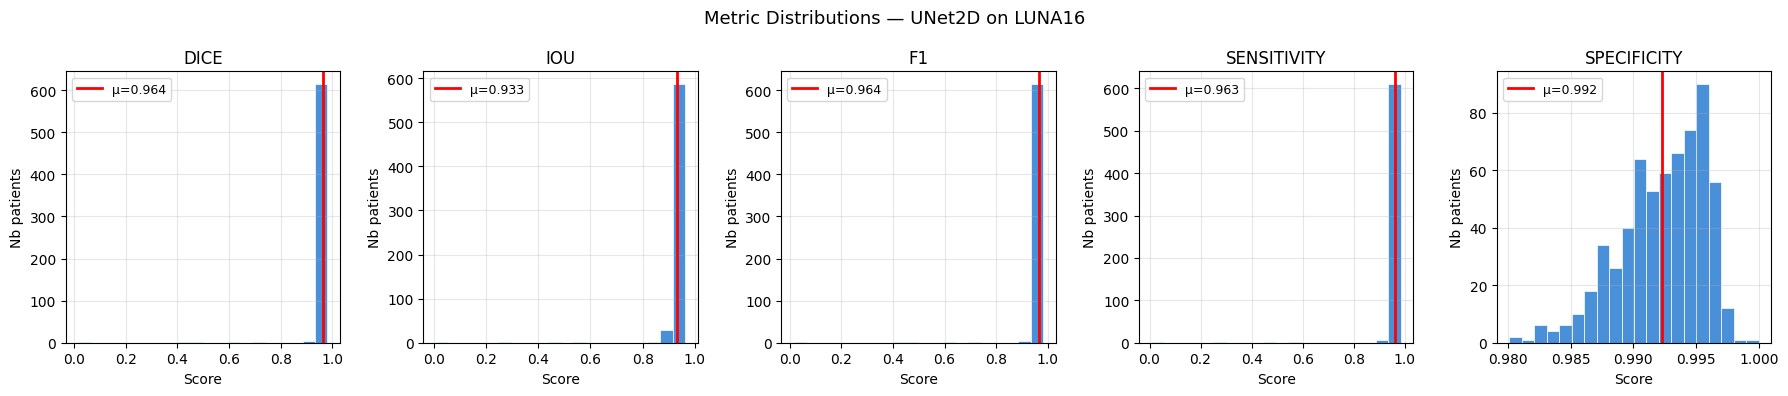

 Figure saved


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

metrics_keys = ["dice", "iou", "f1", "sensitivity", "specificity"]
fig, axes = plt.subplots(1, len(metrics_keys), figsize=(18, 4))
fig.suptitle("Metric Distributions — UNet2D on LUNA16", fontsize=13)

for ax, key in zip(axes, metrics_keys):
    vals = [m[key] for m in all_metrics_list_global if not np.isnan(m[key])]
    ax.hist(vals, bins=20, color="#4A90D9", edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(vals), color="red", linewidth=2, label=f"μ={np.mean(vals):.3f}")
    ax.set_title(key.upper()); ax.set_xlabel("Score"); ax.set_ylabel("Nb patients")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTS, "metrics_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()
print(" Figure saved")


## Cell 10 — Save and Upload Results to HuggingFace

In [15]:
import json
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)

#  JSON
full_results = {"summary": summary, "per_patient": all_results_global}
json_path = os.path.join(DIR_RESULTS, "validation_results.json")
with open(json_path, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"JSON saved: {json_path}")

#  Report TXT
report_path = os.path.join(DIR_RESULTS, "validation_report.txt")
with open(report_path, "w") as f:
    f.write("=" * 60 + "\n")
    f.write("  VALIDATION REPORT — UNet2D on LUNA16\n")
    f.write(f"  Date      : {summary['timestamp']}\n")
    f.write(f"  Volumes   : {summary['n_volumes']}\n")
    f.write(f"  Threshold : {summary['threshold']}\n")
    f.write(f"  Model     : {REPO_MODEL}\n")
    f.write(f"  Subsets   : {SUBSET_FOLDERS}\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Median':>10}\n")
    f.write("-" * 68 + "\n")
    for k in ["dice","iou","f1","precision","recall","sensitivity","specificity","hd95","vol_error_%"]:
        s = summary[k]
        f.write(f"{k:<20} {s['mean']:>10.4f} {s['std']:>10.4f} "
                f"{s['min']:>10.4f} {s['max']:>10.4f} {s['median']:>10.4f}\n")
    f.write("\n\n--- Results par patient ---\n\n")
    for pid, m in all_results_global.items():
        f.write(f"[{pid}]\n")
        for mk, mv in m.items():
            f.write(f"  {mk:<15} = {mv:.6f}\n")
        f.write("\n")
print(f"TXT report saved: {report_path}")

#  Upload tout sur HF
try:
    api.create_repo(repo_id=REPO_RESULTS, repo_type="dataset", exist_ok=True)
except Exception: pass

files_to_upload = [
    json_path, report_path,
    os.path.join(DIR_RESULTS, "metrics_distribution.png"),
]

print(f"\nUploading results to {REPO_RESULTS} ...")
for fpath in files_to_upload:
    if os.path.exists(fpath):
        fname = os.path.basename(fpath)
        try:
            api.upload_file(
                path_or_fileobj=fpath,
                path_in_repo=f"validation/{fname}",
                repo_id=REPO_RESULTS,
                repo_type="dataset"
            )
            print(f"   {fname}")
        except Exception as e:
            print(f"   {fname}: {e}")
    else:
        print(f"    Absent : {fpath}")

print(f"\nPIPELINE COMPLETE!")
print(f"  .h5        -> https://huggingface.co/datasets/{REPO_H5_OUTPUT}")
print(f"  Results    -> https://huggingface.co/datasets/{REPO_RESULTS}")


JSON saved: /content/results/validation_results.json
TXT report saved: /content/results/validation_report.txt

Uploading results to hourouu/LUNA16_validation ...
   validation_results.json
   validation_report.txt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../metrics_distribution.png: 100%|##########| 56.0kB / 56.0kB            

   metrics_distribution.png

PIPELINE COMPLETE!
  .h5        -> https://huggingface.co/datasets/hourouu/LUNA16_preprocessed
  Results    -> https://huggingface.co/datasets/hourouu/LUNA16_validation


Listing hourouu/LUNA16_preprocessed/subset3/ ...
  89 .h5 found in subset3/
  Selected patients: ['1.3.6.1.4.1.14519.5.2.1.6279.6', '1.3.6.1.4.1.14519.5.2.1.6279.6', '1.3.6.1.4.1.14519.5.2.1.6279.6']



subset3/1.3.6.1.4.1.14519.5.2.1.6279.600(…):   0%|          | 0.00/5.99M [00:00<?, ?B/s]

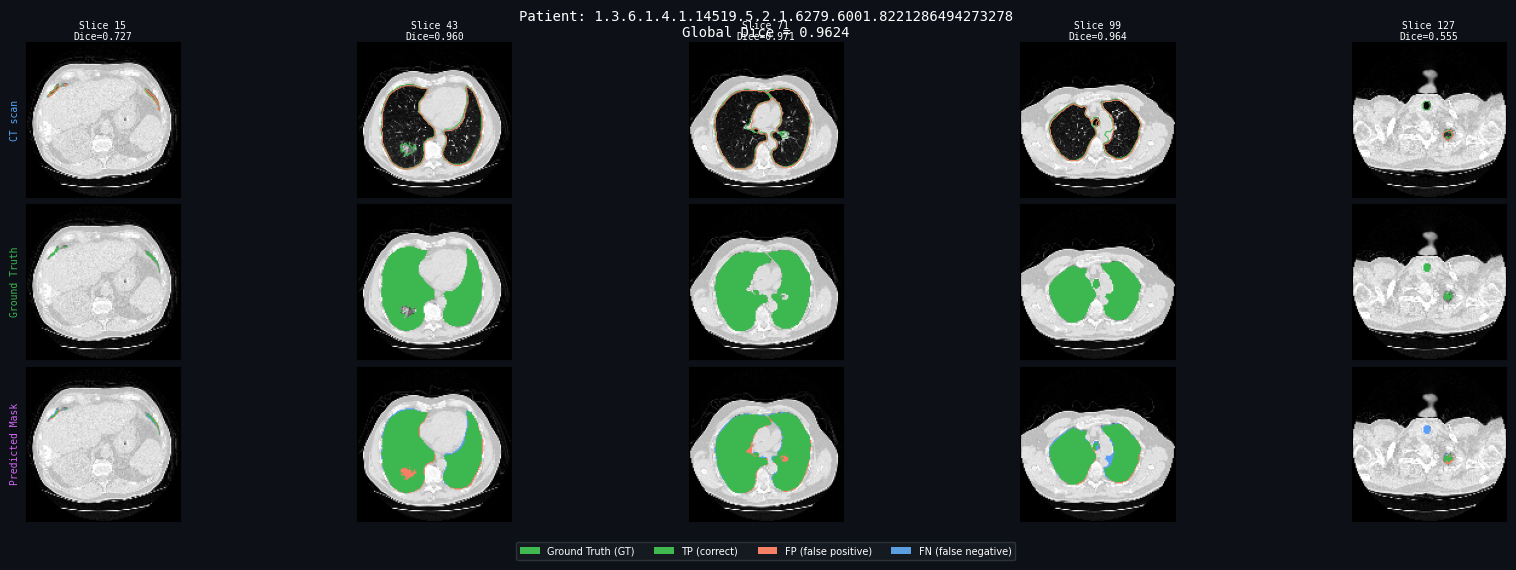

  [1.3.6.1.4.1.14519.5.2.1.6279.6001.822128]  Dice = 0.9624



subset3/1.3.6.1.4.1.14519.5.2.1.6279.600(…):   0%|          | 0.00/7.56M [00:00<?, ?B/s]

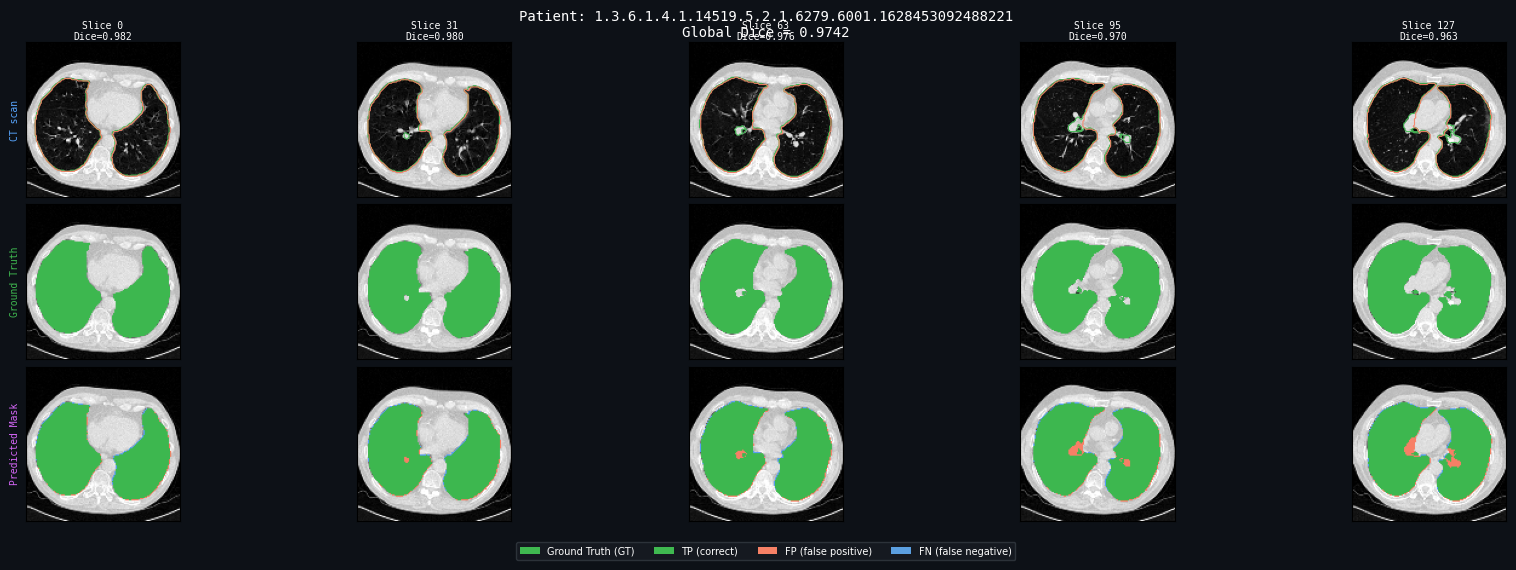

  [1.3.6.1.4.1.14519.5.2.1.6279.6001.162845]  Dice = 0.9742



subset3/1.3.6.1.4.1.14519.5.2.1.6279.600(…):   0%|          | 0.00/6.06M [00:00<?, ?B/s]

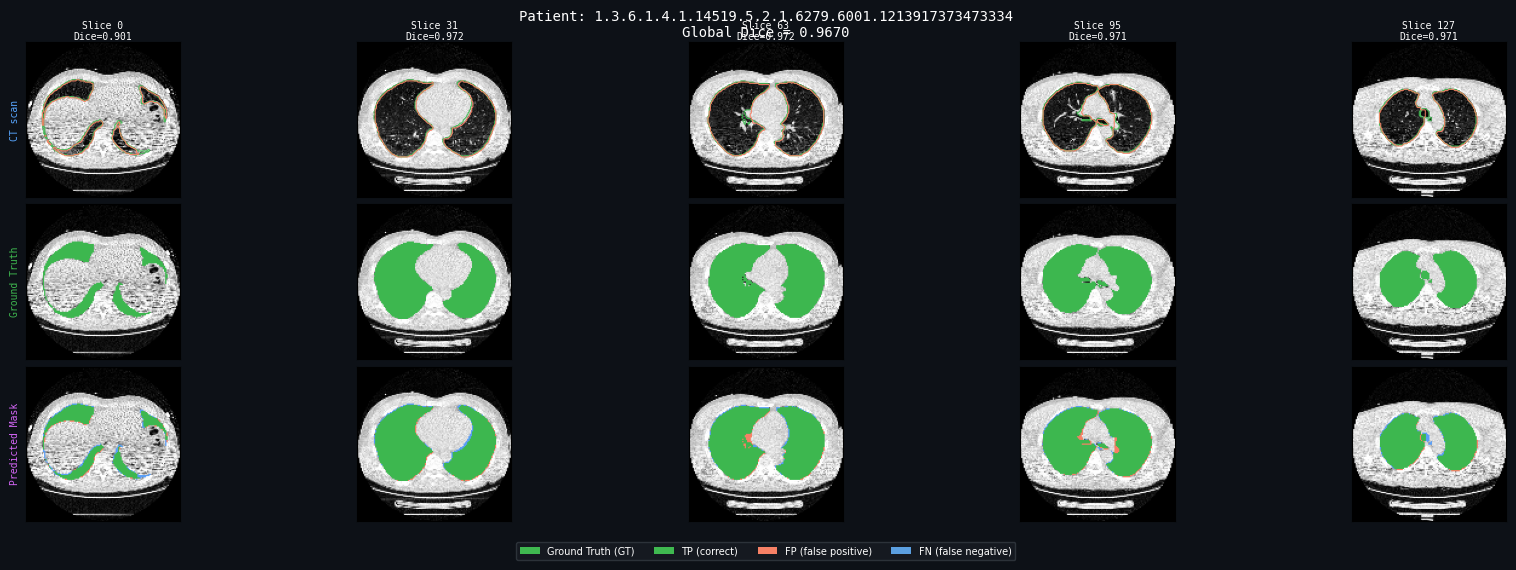

  [1.3.6.1.4.1.14519.5.2.1.6279.6001.121391]  Dice = 0.9670


In [ ]:
#
# CELLULE VISUALISATION — CT | Ground Truth Mask | Predicted Mask | Overlay
# Run AFTER the model loading cell (Cell 5)
# Prerequisites: model, DEVICE, THRESHOLD, REPO_H5_OUTPUT, HF_TOKEN defined
#

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py, torch, random, os
from pathlib import Path
from huggingface_hub import hf_hub_download, list_repo_files

# -- Parameters ---------------------------------------------------------------
N_PATIENTS   = 3        # number of patients to visualize
N_SLICES     = 5        # number of slices per patient
SUBSET       = "subset6"
RANDOM_SEED  = 42

# -- 1. List available .h5 files for this subset -----------------------------
print(f"Listing {REPO_H5_OUTPUT}/{SUBSET}/ ...")
try:
    all_files = list(list_repo_files(repo_id=REPO_H5_OUTPUT, repo_type="dataset", token=HF_TOKEN))
    h5_files  = [f for f in all_files if f.startswith(f"{SUBSET}/") and f.endswith(".h5")]
    print(f"  {len(h5_files)} .h5 found in {SUBSET}/")
except Exception as e:
    raise RuntimeError(f"Could not list {REPO_H5_OUTPUT}: {e}")

if not h5_files:
    raise ValueError(f"No .h5 in {SUBSET}/ — check SUBSET or REPO_H5_OUTPUT")

# -- 2. Randomly select N_PATIENTS -------------------------------------------
random.seed(RANDOM_SEED)
selected = random.sample(h5_files, min(N_PATIENTS, len(h5_files)))
print(f"  Selected patients: {[Path(f).stem[:30] for f in selected]}")


# -- 4. Patient loop ----------------------------------------------------------
CACHE_DIR = "/content/visu_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

model.eval()

for hf_path in selected:
    uid = Path(hf_path).stem

    # Download .h5 if not cached
    local_h5 = os.path.join(CACHE_DIR, f"{uid}.h5")
    if not os.path.exists(local_h5):
        print(f"\nDownloading {uid[:40]} ...")
        local_h5 = hf_hub_download(
            repo_id=REPO_H5_OUTPUT,
            filename=hf_path,
            repo_type="dataset",
            token=HF_TOKEN,
            local_dir=CACHE_DIR
        )

        # Load image + ground truth mask
    with h5py.File(local_h5, "r") as f:
        image = f["image"][:]   # (128, 128, 128) float32 normalized [0,1]
        mask  = f["mask"][:]    # (128, 128, 128) binary float32

        # Slice-by-slice inference
    pred_volume = np.zeros_like(mask)
    with torch.no_grad():
        for i in range(image.shape[0]):
            slc  = torch.from_numpy(image[i]).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
            prob = torch.sigmoid(model(slc)).cpu().numpy()[0, 0]
            pred_volume[i] = (prob > THRESHOLD).astype(np.float32)

        # Global Dice for this patient
    dice_global = dice_score(pred_volume, mask)

        # -- Select the most informative slices (with lung content) ---------------
    lung_presence = mask.sum(axis=(1, 2))           # mask content per slice
    valid_idx     = np.where(lung_presence > 50)[0]  # slices with enough lung content

    if len(valid_idx) < N_SLICES:
        valid_idx = np.arange(image.shape[0])

        # Evenly space across valid slices
    chosen_idx = valid_idx[np.linspace(0, len(valid_idx)-1, N_SLICES, dtype=int)]

        # -- Figure ---------------------------------------------------------------
    fig = plt.figure(figsize=(N_SLICES * 3.5, 5.5), facecolor="#0d1117")
    fig.suptitle(
        f"Patient: {uid[:50]}\nGlobal Dice = {dice_global:.4f}",
        fontsize=10, color="white", y=1.6, ha="center",
        fontfamily="monospace"
    )

        # 3 rows x N_SLICES columns
    gs = gridspec.GridSpec(3, N_SLICES, hspace=0.05, wspace=0.04,
                           top=1.5, bottom=0.08, left=0.03, right=0.97)

    row_labels = ["CT scan", "Ground Truth", "Predicted Mask"]
    row_colors = ["#58a6ff", "#3fb950", "#d466f7"]

    for col, sl_idx in enumerate(chosen_idx):
        ct_sl   = image[sl_idx]
        gt_sl   = mask[sl_idx]
        pred_sl = pred_volume[sl_idx]
        d_slice = dice_score(pred_sl, gt_sl)

        data_rows = [ct_sl, gt_sl, pred_sl]

        for row in range(3):
            ax = fig.add_subplot(gs[row, col])
            ax.set_xticks([]); ax.set_yticks([])

            if row == 0:
                # CT en niveaux de gris
                ax.imshow(data_rows[row], cmap="gray", vmin=0, vmax=1)
                                # Ground truth contour in green
                ax.contour(gt_sl,   levels=[0.5], colors=["#3fb950"], linewidths=0.8, alpha=0.9)
                                # Predicted mask contour in red
                ax.contour(pred_sl, levels=[0.5], colors=["#f78166"], linewidths=0.8, alpha=0.9)
                ax.set_title(f"Slice {sl_idx}\nDice={d_slice:.3f}",
                             fontsize=7, color="white", pad=2, fontfamily="monospace")

            elif row == 1:
                # Ground truth mask in green
                overlay = np.stack([ct_sl]*3, axis=-1)
                overlay_gt = overlay.copy()
                overlay_gt[gt_sl > 0.5] = [0.24, 0.72, 0.31]  # vert
                ax.imshow(overlay_gt)

            else:
                # Predicted mask: green=TP, red=FP, bleu si FN
                tp = (pred_sl > 0.5) & (gt_sl > 0.5)
                fp = (pred_sl > 0.5) & (gt_sl < 0.5)
                fn = (pred_sl < 0.5) & (gt_sl > 0.5)
                rgb = np.stack([ct_sl]*3, axis=-1)
                rgb[tp] = [0.24, 0.72, 0.31]   # green  — correct
                rgb[fp] = [0.97, 0.50, 0.40]   # red    — false positive
                rgb[fn] = [0.35, 0.62, 0.97]   # blue   — false negative
                ax.imshow(rgb)

                        # Row label on the first column
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=7, color=row_colors[row],
                              rotation=90, labelpad=4, fontfamily="monospace")

        # Legend at the bottom
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#3fb950", label="Ground Truth (GT)"),
        Patch(facecolor="#3fb950", label="TP (correct)"),
        Patch(facecolor="#f78166", label="FP (false positive)"),
        Patch(facecolor="#5b9fe0", label="FN (false negative)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=7, facecolor="#161b22", edgecolor="#30363d",
               labelcolor="white", framealpha=0.9,
               bbox_to_anchor=(0.5, 0.0))

    plt.savefig(f"/content/visu_{uid[-30:]}.png", dpi=130, bbox_inches="tight",
                facecolor="#0d1117")
    
    plt.show()
    print(f"  [{uid[:40]}]  Dice = {dice_global:.4f}")
